exp 2

In [ ]:
# -------------------------------
# SLP USING SCIKIT-LEARN
# -------------------------------

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Select only two classes (binary)
X = X[y != 2]
y = y[y != 2]

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Build SLP model
slp = Perceptron(max_iter=1000, eta0=0.01, random_state=42)

# 6. Train model
slp.fit(X_train, y_train)

# 7. Prediction
y_pred = slp.predict(X_test)

# 8. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[12  0]
 [ 0  8]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:
# -------------------------------
# MLP USING SCIKIT-LEARN
# -------------------------------

from sklearn.neural_network import MLPClassifier

# 1. Load full Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Build MLP model
mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10),  # two hidden layers
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# 5. Train model
mlp.fit(X_train, y_train)

# 6. Prediction
y_pred = mlp.predict(X_test)

# 7. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



exp 3

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9199 - loss: 0.2822 - val_accuracy: 0.9638 - val_loss: 0.1313
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9636 - loss: 0.1258 - val_accuracy: 0.9712 - val_loss: 0.0990
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9743 - loss: 0.0862 - val_accuracy: 0.9750 - val_loss: 0.0847
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9809 - loss: 0.0640 - val_accuracy: 0.9717 - val_loss: 0.0870
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9854 - loss: 0.0494 - val_accuracy: 0.9777 - val_loss: 0.0756
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9746 - loss: 0.0774
Test Accuracy: 0.9746000170707703
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


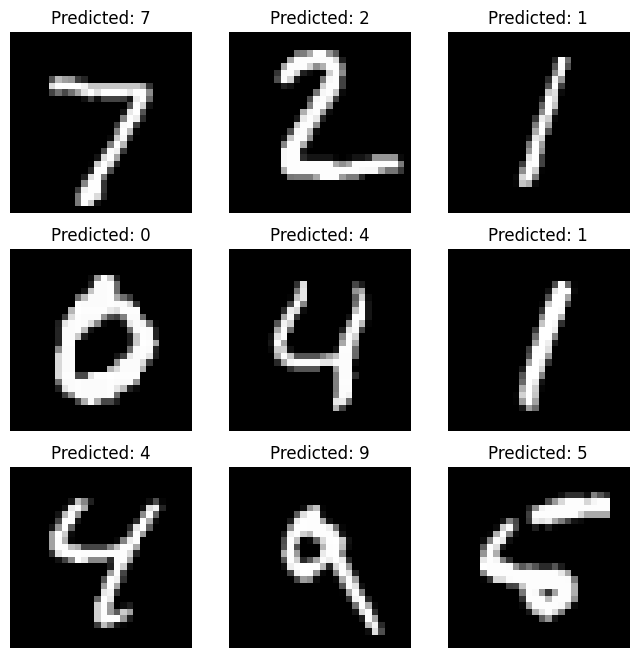

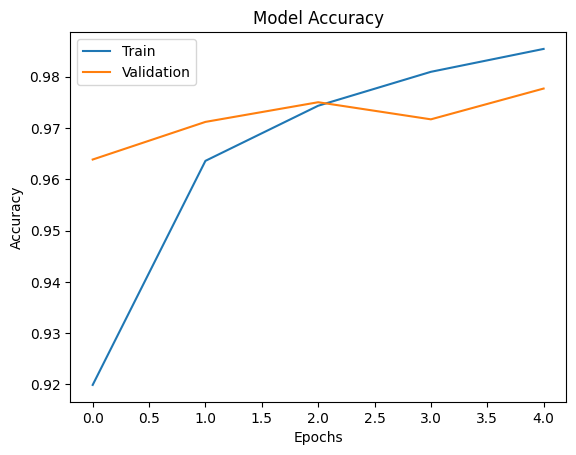

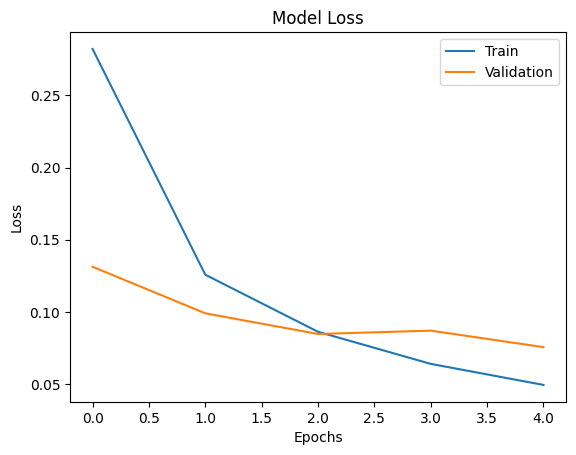

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
import numpy as np
# You have to explain for the
# Step 1: Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Step 2: Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Step 3: Build Neural Network
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Step 4: Compile model # Pratiksha Okay then thank you very much okay the pen return with thanks
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# Meri Taqdeer Ho Gaya Why
# Step 5: Train model
history = model.fit(X_train, y_train, epochs=5, validation_split=0.1)



# Step 6: Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

# ---------------- VISUALIZATION ----------------

# Visualization 1: Sample test images with predictions
predictions = model.predict(X_test)

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[i])}")
    plt.axis('off')
plt.show()

# Visualization 2: Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Visualization 3: Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()


exp 4

(50000, 32, 32, 3)
(10000, 32, 32, 3)
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 296ms/step - accuracy: 0.0887 - loss: 2.5637
Test Accuracy: 0.08869999647140503
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 304ms/step


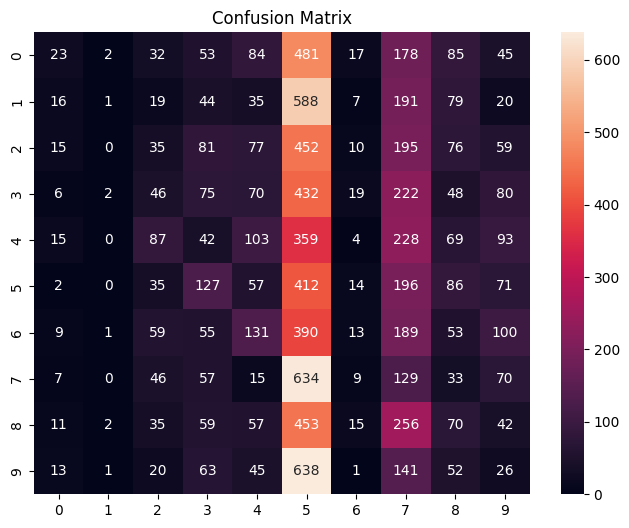

              precision    recall  f1-score   support

           0       0.20      0.02      0.04      1000
           1       0.11      0.00      0.00      1000
           2       0.08      0.04      0.05      1000
           3       0.11      0.07      0.09      1000
           4       0.15      0.10      0.12      1000
           5       0.09      0.41      0.14      1000
           6       0.12      0.01      0.02      1000
           7       0.07      0.13      0.09      1000
           8       0.11      0.07      0.08      1000
           9       0.04      0.03      0.03      1000

    accuracy                           0.09     10000
   macro avg       0.11      0.09      0.07     10000
weighted avg       0.11      0.09      0.07     10000



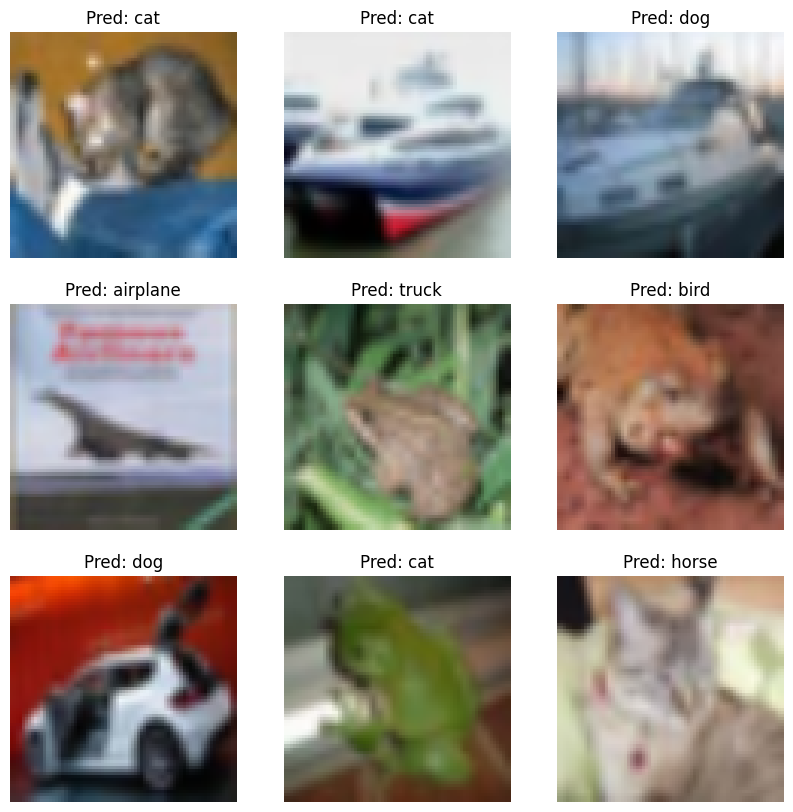

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

SEED_VALUE = 42
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(X_train.shape)
print(X_test.shape)

X_train = tf.image.resize(X_train, (75,75)) / 255.0
X_test = tf.image.resize(X_test, (75,75)) / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

base_model = InceptionV3(weights='imagenet',
                         include_top=False,
                         input_shape=(75,75,3))

base_model.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])
    plt.axis('off')
    plt.title("Pred: " + class_names[y_pred[i]])

plt.show()


exp 5

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Sample temperature data
data = np.array([30, 32, 31, 29, 28, 27, 26, 25, 24, 23])

# Prepare dataset
X, y = [], []
for i in range(len(data)-3):
    X.append(data[i:i+3])
    y.append(data[i+3])

X = np.array(X)
y = np.array(y)

# Build RNN model
model = Sequential()
model.add(SimpleRNN(10, activation='relu', input_shape=(3,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X, y, epochs=100, verbose=0)

# Predict
pred = model.predict(X)
print("Predicted:", pred)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Predicted: [[28.444654]
 [27.865396]
 [26.745066]
 [25.574644]
 [24.663034]
 [23.751427]
 [22.839815]]


exp 6

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense

# Sample normal data
data = np.random.normal(0, 1, (100, 10, 1))

# Build LSTM Autoencoder
model = Sequential()
model.add(LSTM(16, activation='relu', input_shape=(10,1)))
model.add(RepeatVector(10))
model.add(LSTM(16, activation='relu', return_sequences=True))
model.add(TimeDistributed(Dense(1)))

model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(data, data, epochs=20, batch_size=8, verbose=0)

# Reconstruction
reconstructed = model.predict(data)

# Calculate error
loss = np.mean(np.abs(data - reconstructed), axis=(1,2))

print("Reconstruction Error:", loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step
Reconstruction Error: [0.55477606 0.73736808 0.55869014 0.67998648 0.53589954 0.82436565
 0.77680297 0.76824021 0.71514941 0.80579649 0.71272273 0.74468275
 0.92536907 0.68621618 0.548289   0.77983736 1.0917398  0.69256334
 0.59350245 0.7196325  1.00542173 0.61939098 0.86401975 1.09231225
 0.85226453 0.92309178 0.77094469 0.78409412 0.77327016 0.76358819
 0.8001252  1.2115251  0.42676539 0.51514801 0.8146889  0.54921434
 0.55992201 0.67889082 0.61011391 0.81603032 0.52870511 0.73236475
 0.86081516 0.49747675 0.40944676 1.08820778 0.38521761 0.41101936
 0.77096539 0.75309689 0.64678387 0.57495749 0.86267065 0.79607976
 0.82426068 0.89722    1.0649467  0.53872044 0.91557943 0.76270934
 0.77931543 0.65060298 0.47469231 0.4762047  0.76038888 0.39407139
 0.76932943 0.71286684 0.79457514 0.60637818 0.68253918 0.94908619
 0.87213652 0.46352668 0.65040156 0.87138571 0.69393907 0.57148006
 0.47444874 0.8923613  0.51679545 0.81880405 0.88975083 0.7784088
 0

exp 7

Saving 000002.jpg to 000002.jpg
Saving 000008.jpg to 000008.jpg
Saving 000023.jpg to 000023.jpg
Saving 000055.jpg to 000055.jpg
Saving 000069.jpg to 000069.jpg
Saving 000086.jpg to 000086.jpg
Saving 000089.jpg to 000089.jpg
Saving 000103.jpg to 000103.jpg
Saving 000131.jpg to 000131.jpg
Saving 000140.jpg to 000140.jpg
Saving 000152.jpg to 000152.jpg
Saving 000156.jpg to 000156.jpg


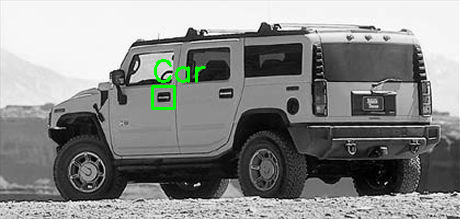

In [ ]:
# Install
!pip install -q opencv-python

# Import
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

# Load built-in car detection model (Haar Cascade)
!wget -q https://raw.githubusercontent.com/andrewssobral/vehicle_detection_haarcascades/master/cars.xml

car_cascade = cv2.CascadeClassifier('cars.xml')

# Upload image
uploaded = files.upload()

# Read image
img = cv2.imread(list(uploaded.keys())[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect cars
cars = car_cascade.detectMultiScale(gray, 1.1, 1)

# Draw boxes
for (x, y, w, h) in cars:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
    cv2.putText(img, "Car", (x, y-5), 0, 1, (0,255,0), 2)

# Show result
cv2_imshow(img)

exp 8

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize data
x_train, x_test = x_train / 255.0, x_test / 255.0

# Build CNN Model
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(x_train, y_train, epochs=10)

# Evaluate model
model.evaluate(x_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 55ms/step - accuracy: 0.4725 - loss: 1.4672
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6094 - loss: 1.1148
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6548 - loss: 0.9895
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 43ms/step - accuracy: 0.6807 - loss: 0.9157
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7018 - loss: 0.8511
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7229 - loss: 0.8006
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7365 - loss: 0.7557
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7503 - loss: 0.7147
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.7657 - loss: 0.6733
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.7782 - loss: 0.6367
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6951 - loss: 0.9249


[0.9248511791229248, 0.6951000094413757]

In [ ]:
# ============================================================
# EXP 9 - Pneumonia Detection (SIMPLIFIED - NO DATASET ERROR)
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

# 1. Load Dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Convert to binary (just for demo)
y_train = (y_train > 4).astype(int)
y_test = (y_test > 4).astype(int)

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# 2. Build CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# 3. Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Train
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# 5. Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.6521 - loss: 0.6161 - val_accuracy: 0.6922 - val_loss: 0.5771
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.7268 - loss: 0.5360 - val_accuracy: 0.7350 - val_loss: 0.5303
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.7650 - loss: 0.4801 - val_accuracy: 0.7626 - val_loss: 0.4803
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 48ms/step - accuracy: 0.7928 - loss: 0.4339 - val_accuracy: 0.7812 - val_loss: 0.4630
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.8204 - loss: 0.3866 - val_accuracy: 0.7832 - val_loss: 0.4597
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7832 - loss: 0.4597
Test Accuracy: 0.7832000255584717


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch: 0
Epoch: 1000
Epoch: 2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


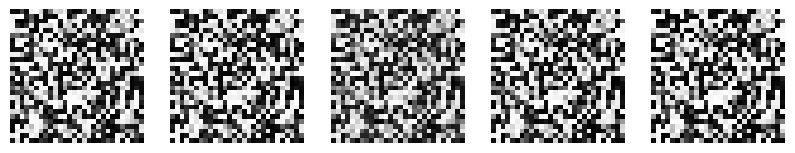

In [ ]:
# ============================================================
# EXP 10 - GAN for Handwritten Digit Generation
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers

# 1. Load Dataset
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [-1,1]
X_train = (X_train - 127.5) / 127.5
X_train = X_train.reshape(-1, 28, 28, 1)

# 2. Generator
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=100),
        layers.Dense(256, activation='relu'),
        layers.Dense(784, activation='tanh'),
        layers.Reshape((28,28,1))
    ])
    return model

# 3. Discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28,28,1)),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()

# Compile discriminator
discriminator.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# 4. GAN Model
discriminator.trainable = False
gan_input = layers.Input(shape=(100,))
fake_img = generator(gan_input)
gan_output = discriminator(fake_img)

gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Training
epochs = 3000
batch_size = 64

for epoch in range(epochs):
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_imgs = X_train[idx]

    noise = np.random.normal(0,1,(batch_size,100))
    fake_imgs = generator.predict(noise, verbose=0)

    discriminator.train_on_batch(real_imgs, np.ones((batch_size,1)))
    discriminator.train_on_batch(fake_imgs, np.zeros((batch_size,1)))

    noise = np.random.normal(0,1,(batch_size,100))
    gan.train_on_batch(noise, np.ones((batch_size,1)))

    if epoch % 1000 == 0:
        print("Epoch:", epoch)

# 6. Generate Images
noise = np.random.normal(0,1,(5,100))
gen_imgs = generator.predict(noise)

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(gen_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# ============================================================
# END
# ============================================================

exp 11

Saving -Blvd-Antonio-l-Rodriguez-188-Conference-Room-Member-Engagement-1-1440x810_jpg.rf.6baa32821f6048d6c6a3ca955a2e179e.jpg to -Blvd-Antonio-l-Rodriguez-188-Conference-Room-Member-Engagement-1-1440x810_jpg.rf.6baa32821f6048d6c6a3ca955a2e179e.jpg
Saving -Blvd-Antonio-l-Rodriguez-188-Conference-Room-Member-Engagement-1-1440x810_jpg.rf.e90c5812ff9c053562c1c36bf752fef0.jpg to -Blvd-Antonio-l-Rodriguez-188-Conference-Room-Member-Engagement-1-1440x810_jpg.rf.e90c5812ff9c053562c1c36bf752fef0.jpg
Saving -Blvd-Antonio-l-Rodriguez-188-Conference-Room-Member-Engagement-1-1440x810_jpg.rf.f6b8f36c7f950c051dae7c256e4300d4.jpg to -Blvd-Antonio-l-Rodriguez-188-Conference-Room-Member-Engagement-1-1440x810_jpg.rf.f6b8f36c7f950c051dae7c256e4300d4.jpg
Saving -teamwork-technology-concept-team-laptop-computer-papers-smartphone-47058462_jpg.rf.2c7870c1872d2fe0340d27dbc2c8cf7a.jpg to -teamwork-technology-concept-team-laptop-computer-papers-smartphone-47058462_jpg.rf.2c7870c1872d2fe0340d27dbc2c8cf7a.jpg
Savi

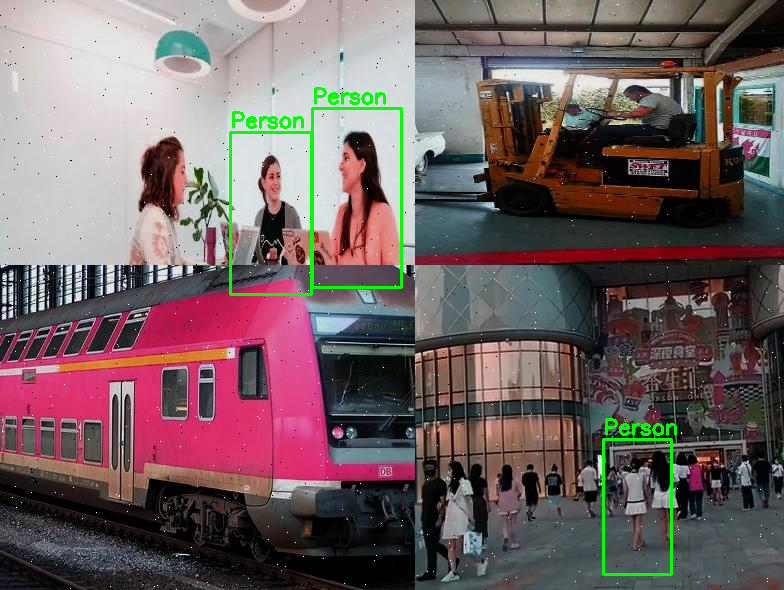

In [ ]:
# Install
!pip install -q opencv-python

# Import
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload image
uploaded = files.upload()

# Read image
img = cv2.imread(list(uploaded.keys())[0])

# Load HOG + SVM person detector
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

# Detect persons
boxes, weights = hog.detectMultiScale(img, winStride=(8,8))

# Draw bounding boxes
for (x, y, w, h) in boxes:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
    cv2.putText(img, "Person", (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

# Show output
cv2_imshow(img)

exp 12

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error

data = np.arange(100)

X, y = [], []
for i in range(len(data)-3):
    X.append(data[i:i+3])
    y.append(data[i+3])

X, y = np.array(X), np.array(y)

model = Sequential()
model.add(LSTM(10, input_shape=(3,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=10, verbose=0)

pred = model.predict(X)

print("MAE:", mean_absolute_error(y, pred))
print("RMSE:", np.sqrt(mean_squared_error(y, pred)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step
MAE: 50.891334533691406
RMSE: 58.07213447716878


exp 13

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np # Explicitly import numpy

texts = ["good", "bad", "toxic", "nice"]
labels = [0,1,1,0]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences)

# Explicitly convert X and labels to tf.constant to ensure proper data type handling
X = tf.constant(X)
labels = tf.constant(labels)

# Get vocabulary size for clarity in Embedding layer
vocab_size = len(tokenizer.word_index) + 1 # +1 for padding token

model = Sequential()
# Removed 'input_length' as it is deprecated and can be inferred by Keras
model.add(Embedding(input_dim=vocab_size, output_dim=8))
model.add(LSTM(8))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X, labels, epochs=5, verbose=1)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.6895
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.6890
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.6885
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.6880
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.6875


exp 14

In [ ]:
# Install transformers
!pip install -q transformers

from transformers import pipeline

# Load model
classifier = pipeline("text-classification")

# Test emails
emails = [
    "I need help with my order",
    "Congratulations! You won a prize",
    "Your account has been updated"
]

# Predict
for mail in emails:
    result = classifier(mail)
    print(mail, "->", result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

I need help with my order -> [{'label': 'NEGATIVE', 'score': 0.9974754452705383}]
Congratulations! You won a prize -> [{'label': 'POSITIVE', 'score': 0.9998465776443481}]
Your account has been updated -> [{'label': 'POSITIVE', 'score': 0.9555497765541077}]


exp 15

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 0b8dabb7-5f1b-4fdc-b3fa-30b289707b90___JR_FrgE.S 3047_90deg.JPG to 0b8dabb7-5f1b-4fdc-b3fa-30b289707b90___JR_FrgE.S 3047_90deg.JPG
Saving 0b37761a-de32-47ee-a3a4-e138b97ef542___JR_FrgE.S 2908_new30degFlipLR.JPG to 0b37761a-de32-47ee-a3a4-e138b97ef542___JR_FrgE.S 2908_new30degFlipLR.JPG
Saving 0bc40cc3-6a85-480e-a22f-967a866a56a1___JR_FrgE.S 2784_90deg.JPG to 0bc40cc3-6a85-480e-a22f-967a866a56a1___JR_FrgE.S 2784_90deg.JPG
Saving 0bc40cc3-6a85-480e-a22f-967a866a56a1___JR_FrgE.S 2784_270deg.JPG to 0bc40cc3-6a85-480e-a22f-967a866a56a1___JR_FrgE.S 2784_270deg.JPG
Saving 0c7c7992-fb1c-444b-b226-69de186cea14___JR_FrgE.S 8627_90deg.JPG to 0c7c7992-fb1c-444b-b226-69de186cea14___JR_FrgE.S 8627_90deg.JPG
Saving 0c7c7992-fb1c-444b-b226-69de186cea14___JR_FrgE.S 8627_270deg.JPG to 0c7c7992-fb1c-444b-b226-69de186cea14___JR_FrgE.S 8627_270deg.JPG
Saving 0c8432e0-0484-470c-a774-7cce596b9e64___JR_FrgE.S 2841_new30degFlipLR.JPG to 0c8432e0-0484-470c-a774-7cce596b9e64___JR_FrgE.S 2841_new30degFlipL

To prepare your dataset for `ImageDataGenerator.flow_from_directory()`, you need to organize your images into a main directory (e.g., `dataset`) with subdirectories, where each subdirectory represents a class. For example:

```
/content/dataset/
  class_a/
    image1.jpg
    image2.png
  class_b/
    image3.jpg
    image4.png
```

The following code snippet demonstrates how to create this structure. You'll need to modify the `image_files` list and the `class_mapping` dictionary to reflect your actual image filenames, their current locations, and the classes they belong to.

In [ ]:
# Install
!pip install -q tensorflow

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Load dataset (folder structure required)
train_data = train_datagen.flow_from_directory(
    '/content/dataset',   # Fixed: Pointing to the newly created dataset folder
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical'
)

# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
model.fit(train_data, epochs=3)

print("Training Completed ")

Found 74 images belonging to 1 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 621ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 2/3
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 363ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 3/3
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 383ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Training Completed 
